# NZZ ContextAI — Explorer Notebook
Datenexploration und Pipeline-Test mit den NZZ JSON-Daten.

## 1. Setup

In [2]:
import sys
sys.path.append('../src')

import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

from config import NZZ_JSON_GLOB, EMBEDDING_MODEL, CHROMA_PATH, CHROMA_COLLECTION, USE_RERANKING
from preprocess import load_dataset, preprocess, strip_html
from chunking import chunk_dataframe

print("Setup abgeschlossen.")
print(f"NZZ JSON Glob: {NZZ_JSON_GLOB}")

Setup abgeschlossen.
NZZ JSON Glob: /home/florentin/DSPRO/notebooks/../data/raw/articles_*.json


## 2. Rohdaten-Struktur
Einzelne JSON-Datei inspizieren — Felder und Datenqualität verstehen.

In [3]:
# Eine Datei laden und Wrapper-Struktur zeigen
sample_file = sorted(glob.glob(NZZ_JSON_GLOB))[-1]  # neueste Datei
with open(sample_file) as f:
    raw = json.load(f)

# Struktur: entweder [{...}] oder {...}
wrapper = raw[0] if isinstance(raw, list) else raw
result  = wrapper.get("result", [])

print(f"Datei:        {sample_file.split('/')[-1]}")
print(f"searchTime:   {wrapper.get('searchTime')} ms")
print(f"numFound:     {wrapper.get('numFound')} Artikel (gesamt in dieser Suche)")
print(f"result-Länge: {len(result)} Artikel in dieser Datei")

article = result[1]   # Index 1 = erster Volltextartikel (0 oft Multimedia)
print("\n── Felder eines Artikels ──")
for key, val in article.items():
    v = str(val)
    print(f"  {key:<30} {v[:80]}")

Datei:        articles_2025_12.json
searchTime:   2186 ms
numFound:     1763 Artikel (gesamt in dieser Suche)
result-Länge: 1763 Artikel in dieser Datei

── Felder eines Artikels ──
  sperre_flag                    F
  orig_ctx                       nzz-ldocs-online-article-1918392
  art_sei_lk_cnt                 0
  lt_ressort_name                Schweiz
  autor_ctx                      Marc Tribelhorn
  document_id                    336553040#ART
  seite_name                     ['1']
  score                          1
  ressort_id                     [486127]
  artikel_verwend_flag           F
  mandant_id                     203805
  lt_unterressort_name           Schweiz
  media_type                     ART
  honorar_flag                   F
  lt_zeitung_name                nzz.ch
  ausgabe_name                   ['Onlineausgabe']
  aenderungs_ts                  2026-01-02T11:25:19.000Z
  media_id                       336553040
  artikel_online_flag            T
  np_edition_i

In [4]:
# Schlüsselfelder eines Artikels im Klartext
print("TITEL:  ", article.get("ueberschrift_ctx", ""))
print()
print("LEAD:   ", article.get("vorspann_ctx", "")[:300])
print()
body_plain = strip_html(article.get("grundtext_ctx", ""))
print("BODY:   ", body_plain[:400], "...")
print()
print("AUTOR:  ", article.get("autor_ctx", ""))
print("RESSORT:", article.get("lt_ressort_name", ""), "/", article.get("lt_unterressort_name", ""))
print("DATUM:  ", (article.get("published_from_ts") or [""])[0][:10])
print("ID:     ", article.get("media_id"))
print("ZEICHEN:", article.get("zeichenanzahl", 0))

TITEL:   «Der Bundesrat täte gut daran, sich für die gegenüber den verfolgten Juden begangenen Fehler zu entschuldigen»

LEAD:    50 Jahre nach dem Ende von Hitlers Reich hielt Kaspar Villiger eine Rede, die in die Geschichte einging. Nun belegen bisher gesperrte Dokumente, wie schwer sich die Landesregierung mit den Schatten des Zweiten Weltkriegs tat.

BODY:    Die Schweiz ist ein sonderbares Land. 1989 veranstaltet sie behördlich orchestrierte Erinnerungsanlässe zum 50-Jahr-Jubiläum der Mobilmachung der Armee im Zweiten Weltkrieg. Als europaweit einziger Staat – und dazu als einer, der kriegsverschont war. Das löst im Ausland Erstaunen aus. Und im Inland Empörung, zumindest bei den Linken, die mit einer Initiative gerade die Armee abschaffen wollen und  ...

AUTOR:   Marc Tribelhorn
RESSORT: Schweiz / Schweiz
DATUM:   2025-12-31
ID:      336553040
ZEICHEN: 11031


## 3. Datensatz-Überblick
Alle Monatsdateien laden und aggregierte Statistiken berechnen.

In [5]:
# Alle Dateien: Artikel pro Monat
files = sorted(glob.glob(NZZ_JSON_GLOB))
rows = []
for path in files:
    with open(path) as f:
        data = json.load(f)
    wrapper = data[0] if isinstance(data, list) else data
    month = path.split("/")[-1].replace("articles_", "").replace(".json", "")
    n = len(wrapper.get("result", []))
    rows.append({"monat": month, "artikel": n})

monthly = pd.DataFrame(rows)
print(f"Dateien gesamt:  {len(files)}")
print(f"Artikel gesamt:  {monthly['artikel'].sum():,}")
print()
print(monthly.to_string(index=False))

Dateien gesamt:  36
Artikel gesamt:  66,452

  monat  artikel
2023_01     1839
2023_02     1726
2023_03     2051
2023_04     1788
2023_05     1933
2023_06     1995
2023_07     1870
2023_08     1838
2023_09     1997
2023_10     1968
2023_11     2010
2023_12     1786
2024_01     1758
2024_02     1718
2024_03     1803
2024_04     1734
2024_05     1779
2024_06     1833
2024_07     1810
2024_08     1775
2024_09     1811
2024_10     1874
2024_11     1999
2024_12     1722
2025_01     1853
2025_02     1732
2025_03     1943
2025_04     1690
2025_05     1972
2025_06     1827
2025_07     1845
2025_08     1752
2025_09     1866
2025_10     1913
2025_11     1879
2025_12     1763


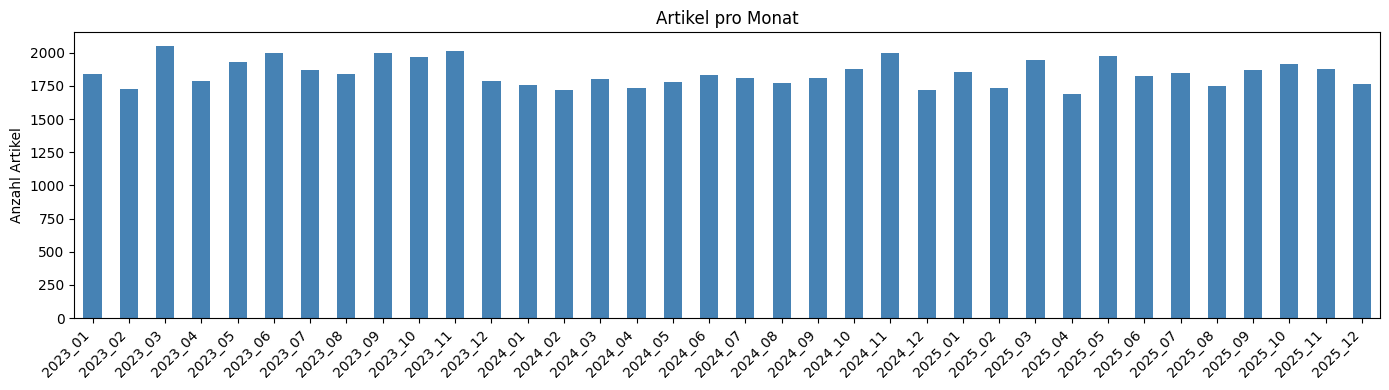

In [6]:
monthly.plot(x="monat", y="artikel", kind="bar", figsize=(14, 4), legend=False, color="steelblue")
plt.title("Artikel pro Monat")
plt.xlabel("")
plt.ylabel("Anzahl Artikel")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Preprocessing testen
`load_dataset()` + `preprocess()` auf den NZZ-Daten — HTML-Stripping, Filterung leerer Artikel, Textlängen.

In [7]:
raw_df = load_dataset()
print(f"Rohdaten:  {len(raw_df):,} Artikel")
print(f"Spalten:   {list(raw_df.columns)}")
print()

# Wie viele haben keinen Body (Multimedia etc.)?
empty = raw_df[raw_df["body"].str.strip() == ""]
print(f"Leere Bodies (Multimedia-Artikel): {len(empty):,}")

df = preprocess(raw_df)
print(f"Nach Preprocessing: {len(df):,} Artikel (gefiltert: {len(raw_df)-len(df):,})")
print()
print("Ressort-Verteilung:")
print(df["category"].value_counts().head(15).to_string())

Rohdaten:  66,452 Artikel
Spalten:   ['article_id', 'title', 'lead', 'body', 'category', 'subcategory', 'author', 'published_date', 'zeitung']

Leere Bodies (Multimedia-Artikel): 333
Nach Preprocessing: 66,072 Artikel (gefiltert: 380)

Ressort-Verteilung:
category
International          11499
Feuilleton              7405
Wirtschaft              7013
Meinung und Debatte     6716
Schweiz                 6348
Sport                   4944
Zürich                  4108
Front                   3656
Wissenschaft            2792
Panorama                2661
Vermischtes             2174
Sonstiges               1898
Finanzen                1045
Gesellschaft            1016
Mobilität                612


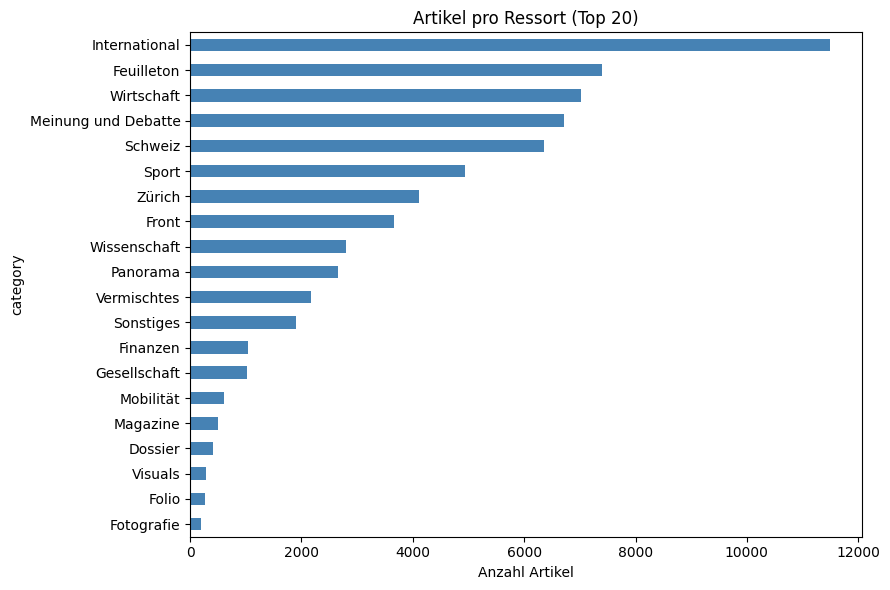

In [8]:
# Ressort-Verteilung als Balkendiagramm
df["category"].value_counts().head(20).plot(
    kind="barh", figsize=(9, 6), color="steelblue"
)
plt.title("Artikel pro Ressort (Top 20)")
plt.xlabel("Anzahl Artikel")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

count     66072.0
mean       6772.0
std        4198.0
min         101.0
25%        4421.0
50%        6123.0
75%        8249.0
max      158273.0


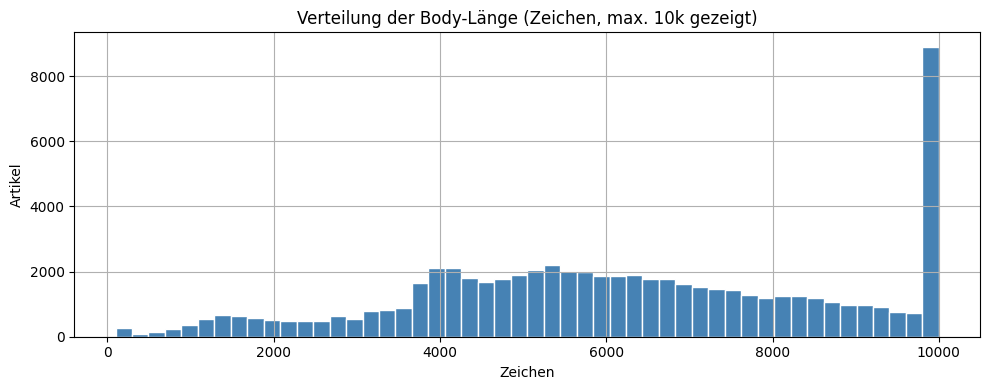

In [9]:
# Body-Länge Verteilung
df["body_len"] = df["body"].str.len()
print(df["body_len"].describe().round(0).to_string())

df["body_len"].clip(upper=10000).hist(bins=50, figsize=(10, 4), color="steelblue", edgecolor="white")
plt.title("Verteilung der Body-Länge (Zeichen, max. 10k gezeigt)")
plt.xlabel("Zeichen")
plt.ylabel("Artikel")
plt.tight_layout()
plt.show()

In [10]:
# Beispielartikel anzeigen
sample = df[df["body_len"] > 2000].iloc[0]
print(f"Titel:    {sample['title']}")
print(f"Autor:    {sample['author']}")
print(f"Ressort:  {sample['category']} / {sample.get('subcategory', '')}")
print(f"Datum:    {sample['published_date']}")
print(f"Zeichen:  {sample['body_len']}")
print()
print("Lead:")
print(sample["lead"])
print()
print("Body (erste 600 Zeichen):")
print(sample["body"][:600], "...")

Titel:    EZB-Präsidentin Lagarde hilft jetzt nur noch ein Sieg über die Inflation
Autor:    Michael Rasch, Frankfurt
Ressort:  Meinung und Debatte / Meinung und Debatte
Datum:    2023-01-31
Zeichen:  9615

Lead:
Die Französin hat zu lange auf ihren starrsinnigen Chefökonomen gehört und sich damit selbst beschädigt. Er redete die Inflation noch klein, als sie bereits auf Rekordniveau lag. Jetzt sollte sich Christine Lagarde mit klarer Inflationsbekämpfung profilieren und so ihr Image verbessern, sonst droht der gleiche Ansehensverlust wie bei ihrem Chefökonomen.

Body (erste 600 Zeichen):
Die Französin hat zu lange auf ihren starrsinnigen Chefökonomen gehört und sich damit selbst beschädigt. Er redete die Inflation noch klein, als sie bereits auf Rekordniveau lag. Jetzt sollte sich Christine Lagarde mit klarer Inflationsbekämpfung profilieren und so ihr Image verbessern, sonst droht der gleiche Ansehensverlust wie bei ihrem Chefökonomen. Die Begebenheit ist nicht ohne Ironie: Sogar die

## 5. Chunking testen

In [11]:
chunks = chunk_dataframe(df)

print(f"Artikel:               {len(df):,}")
print(f"Chunks gesamt:         {len(chunks):,}")
print(f"Ø Chunks pro Artikel:  {len(chunks)/len(df):.1f}")
print()
chunks["chunk_len"] = chunks["chunk_text"].str.len()
print(chunks["chunk_len"].describe().round(0).to_string())
print()
print("Beispiel-Chunk:")
print(chunks.iloc[1].to_string())

Artikel:               66,072
Chunks gesamt:         203,481
Ø Chunks pro Artikel:  3.1

count    203481.0
mean       2838.0
std        1095.0
min          29.0
25%        2083.0
50%        3416.0
75%        3629.0
max        4561.0

Beispiel-Chunk:
article_id                                                311120768
chunk_id                                                311120768-1
chunk_index                                                       1
chunk_text        EZB-Präsidentin Lagarde hilft jetzt nur noch e...
title             EZB-Präsidentin Lagarde hilft jetzt nur noch e...
category                                        Meinung und Debatte
author                                     Michael Rasch, Frankfurt
published_date                                           2023-01-31
chunk_len                                                      3524


## 6. Sample-Embedding & Retrieval testen
Kleines Sample (3 Artikel pro Ressort) in eine temporäre ChromaDB-Collection einbetten und Retrieval testen.  
**Modell wird hier erst geladen** — dauert 1–2 Minuten.

In [12]:
from embed import load_model, embed_chunks, get_chroma_collection

model = load_model(EMBEDDING_MODEL)
print("Modell geladen.")

Lädt embedding model: Qwen/Qwen3-Embedding-0.6B


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Modell geladen.


In [13]:
# 3 Artikel pro Ressort samplen, chunken, embedden
sample_df     = df.groupby("category").head(3).reset_index(drop=True)
sample_chunks = chunk_dataframe(sample_df)
print(f"Sample: {len(sample_df)} Artikel, {len(sample_chunks)} Chunks")

embeddings = embed_chunks(model, sample_chunks["chunk_text"].tolist())

# Temp-Collection (in-memory, kein Schreiben auf Disk)
import chromadb
tmp_client     = chromadb.EphemeralClient()
tmp_collection = tmp_client.get_or_create_collection("explorer_test", metadata={"hnsw:space": "cosine"})

meta_cols = ["article_id", "chunk_index", "title", "category", "author", "published_date"]
tmp_collection.upsert(
    ids        = sample_chunks["chunk_id"].tolist(),
    embeddings = embeddings,
    documents  = sample_chunks["chunk_text"].tolist(),
    metadatas  = sample_chunks[meta_cols].to_dict(orient="records"),
)
print("Sample in temporäre ChromaDB geladen.")

Sample: 96 Artikel, 323 Chunks
Generiere Embeddings für 323 Chunks...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Sample in temporäre ChromaDB geladen.


In [14]:
from retrieval import embed_query, search

# NZZ-spezifische Testqueries
queries = [
    "Wie hat die Schweiz auf den Ukraine-Krieg reagiert?",
    "SNB Zinsentscheid Franken",
    "Bundesratswahl Nachfolge",
    "KI künstliche Intelligenz Regulierung Europa",
    "Klimawandel Gletscher Schweiz",
]

for query in queries:
    q_emb   = embed_query(model, query)
    results = search(tmp_collection, q_emb, top_k=3)
    print(f"Query: {query}")
    for r in results:
        author = f" — {r['author']}" if r.get("author") else ""
        print(f"  [{r['category']}] {r['title'][:65]}{author}  ({r['similarity_score']:.3f})")
    print()

Query: Wie hat die Schweiz auf den Ukraine-Krieg reagiert?
  [Wetter] Wohnungen von Schweizer Diplomaten im Sudan bombardiert  (0.563)
  [Wochenende] Polit-Thriller mit Geiseln und geheimen Fluchtplänen: Als Muammar — Marc Tribelhorn, Marcel Gyr (Text), Anja Lemcke (Illustration)  (0.562)
  [Wochenende] Polit-Thriller mit Geiseln und geheimen Fluchtplänen: Als Muammar — Marc Tribelhorn, Marcel Gyr (Text), Anja Lemcke (Illustration)  (0.544)

Query: SNB Zinsentscheid Franken
  [Meinung und Debatte] EZB-Präsidentin Lagarde hilft jetzt nur noch ein Sieg über die In — Michael Rasch, Frankfurt  (0.410)
  [Meinung und Debatte] EZB-Präsidentin Lagarde hilft jetzt nur noch ein Sieg über die In — Michael Rasch, Frankfurt  (0.394)
  [Meinung und Debatte] EZB-Präsidentin Lagarde hilft jetzt nur noch ein Sieg über die In — Michael Rasch, Frankfurt  (0.384)

Query: Bundesratswahl Nachfolge
  [Bildstrecken] Wo die Regierung mit dem Volk tanzt — Thomas Isler  (0.415)
  [Meinung und Debatte] Die wiede

## 7. Evaluation gegen Ground Truth

Retrieval auf der echten ChromaDB (nicht Sample) gegen die definierten Ground-Truth-Queries messen.  
Metriken: **Hit@1**, **Hit@3**, **Hit@5** — trifft der richtige Artikel unter den Top-K Ergebnissen?

In [15]:
from retrieval import load_models, retrieve

# Modell laden falls noch nicht aus Sektion 6 vorhanden
try:
    model
except NameError:
    model = None

if model is None:
    model, reranker = load_models(use_reranking=USE_RERANKING)
else:
    from sentence_transformers import CrossEncoder
    from config import RERANKER_MODEL
    reranker = CrossEncoder(RERANKER_MODEL) if USE_RERANKING else None
    print("Modell aus Sektion 6 wiederverwendet.")

collection = get_chroma_collection(CHROMA_PATH, CHROMA_COLLECTION)
print(f"ChromaDB verbunden: {collection.count():,} Chunks")
print(f"Reranking aktiv:    {USE_RERANKING}")

Modell aus Sektion 6 wiederverwendet.
ChromaDB verbunden: 5,369 Chunks
Reranking aktiv:    False


In [16]:
from config import EVAL_GROUND_TRUTH, EVAL_TOP_K_RETRIEVAL, EVAL_TOP_K_FINAL

# Ground Truth laden
with open(EVAL_GROUND_TRUTH) as f:
    ground_truth = [json.loads(line) for line in f if line.strip()]

print(f"Ground-Truth-Queries: {len(ground_truth)}")

# Retrieval für jede Query ausführen
TOP_K = EVAL_TOP_K_FINAL   # für Hit@k Berechnung

eval_rows = []
for sample in ground_truth:
    query        = sample["query"]
    relevant_ids = set(sample["relevant_article_ids"])

    results = retrieve(
        query, model, collection, reranker,
        top_k_retrieval=EVAL_TOP_K_RETRIEVAL,
        top_k_rerank=TOP_K,
    )

    returned_ids = [r["article_id"] for r in results]

    hit1 = any(rid in relevant_ids for rid in returned_ids[:1])
    hit3 = any(rid in relevant_ids for rid in returned_ids[:3])
    hit5 = any(rid in relevant_ids for rid in returned_ids[:5])

    best = results[0] if results else {}
    eval_rows.append({
        "query":          query,
        "hit@1":          hit1,
        "hit@3":          hit3,
        "hit@5":          hit5,
        "best_score":     round(best.get("similarity_score", 0), 3),
        "best_title":     best.get("title", "")[:60],
        "best_category":  best.get("category", ""),
        "relevant_ids":   list(relevant_ids),
        "returned_ids":   returned_ids,
        "results":        results,
    })

eval_df = pd.DataFrame(eval_rows)
print("Fertig.")
print(f"\nHit@1: {eval_df['hit@1'].mean():.0%}   Hit@3: {eval_df['hit@3'].mean():.0%}   Hit@5: {eval_df['hit@5'].mean():.0%}")

Ground-Truth-Queries: 14
Fertig.

Hit@1: 71%   Hit@3: 100%   Hit@5: 100%


In [17]:
# ── Übersichts-Tabelle ──────────────────────────────────────────────────────
def style_hit(val):
    return "background-color: #c6efce; color: #276221" if val else "background-color: #ffc7ce; color: #9c0006"

display_df = eval_df[["query", "hit@1", "hit@3", "hit@5", "best_score", "best_title", "best_category"]].copy()
display_df["query"] = display_df["query"].str[:65]

(display_df.style
    .applymap(style_hit, subset=["hit@1", "hit@3", "hit@5"])
    .format({"best_score": "{:.3f}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
)

/tmp/ipykernel_2223/3537212131.py:9: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(style_hit, subset=["hit@1", "hit@3", "hit@5"])


,query,hit@1,hit@3,hit@5,best_score,best_title,best_category
0,Was erwarten Schweizer Anlageprofis für die Börsenmärkte im Jahr,False,True,True,0.723,In der Schweiz ist der Anlagenotstand gross: Das führt zu p,Wirtschaft
1,Werden in der Schweiz wieder Negativzinsen eingeführt?,False,True,True,0.711,Die SNB bleibt beim Nullzins und widerspricht der UBS,Wirtschaft
2,Wie verhält sich Putins Kriegsführung im Vergleich zu Stalin?,True,True,True,0.712,«Putin ist viel draufgängerischer als Stalin»,Feuilleton
3,Was zeigen sowjetische Archivdokumente über die Denkweise russisc,True,True,True,0.640,«Putin ist viel draufgängerischer als Stalin»,Feuilleton
4,Wie werden ukrainische Kinder in Russland umerzogen?,True,True,True,0.771,Die stummen Opfer des Krieges: wie Russland ukrainische Kind,International
5,Russland verschleppt ukrainische Kinder und gibt sie zur Adoption,True,True,True,0.814,Die stummen Opfer des Krieges: wie Russland ukrainische Kind,International
6,Ukrainischer Freiwilliger birgt tote russische Soldaten vom Schla,True,True,True,0.669,«Da liegt ein Fuss im Feld»: Ein Ukrainer riskiert sein Lebe,Gesellschaft
7,Menschlichkeit im Krieg: Umgang mit gefallenen Feinden im Donbass,True,True,True,0.634,«Da liegt ein Fuss im Feld»: Ein Ukrainer riskiert sein Lebe,Gesellschaft
8,Wie hat sich die Schweiz für die Zurückweisung jüdischer Flüchtli,True,True,True,0.709,"«Der Bundesrat täte gut daran, sich für die gegenüber den ve",Schweiz
9,Kaspar Villiger Entschuldigung Bundesrat Holocaust 1995,True,True,True,0.690,"«Der Bundesrat täte gut daran, sich für die gegenüber den ve",Schweiz


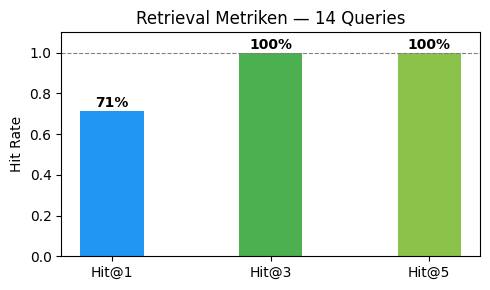

In [18]:
# ── Metriken-Balkendiagramm ─────────────────────────────────────────────────
metrics = {
    "Hit@1": eval_df["hit@1"].mean(),
    "Hit@3": eval_df["hit@3"].mean(),
    "Hit@5": eval_df["hit@5"].mean(),
}
colors = ["#2196F3", "#4CAF50", "#8BC34A"]

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, width=0.4)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Hit Rate")
ax.set_title(f"Retrieval Metriken — {len(eval_df)} Queries")
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.0%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# ── Detail-Ansicht: Top-5 Ergebnisse pro Query ──────────────────────────────
from IPython.display import display, HTML

for row in eval_rows:
    relevant = set(row["relevant_ids"])
    icon     = "✅" if row["hit@5"] else "❌"
    html     = f"<hr><b>{icon} {row['query']}</b><br>"
    html    += f"<small>Hit@1={row['hit@1']} &nbsp; Hit@3={row['hit@3']} &nbsp; Hit@5={row['hit@5']}</small>"
    html    += "<table style='width:100%; font-size:13px; margin-top:6px'>"
    html    += "<tr><th>#</th><th>Score</th><th>Artikel-ID</th><th>Ressort</th><th>Titel</th><th>Autor</th><th>Datum</th></tr>"
    for rank, r in enumerate(row["results"], 1):
        is_hit  = r["article_id"] in relevant
        bg      = "#c6efce" if is_hit else "white"
        marker  = " ✓" if is_hit else ""
        html   += (
            f"<tr style='background:{bg}'>"
            f"<td>{rank}</td>"
            f"<td>{r['similarity_score']:.3f}</td>"
            f"<td>{r['article_id']}{marker}</td>"
            f"<td>{r['category']}</td>"
            f"<td>{r['title'][:70]}</td>"
            f"<td>{r.get('author','')[:25]}</td>"
            f"<td>{r.get('published_date','')}</td>"
            f"</tr>"
        )
    html += "</table>"
    display(HTML(html))

#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.723,336522288,Wirtschaft,In der Schweiz ist der Anlagenotstand gross: Das führt zu potenziell,Markus Städeli,2025-12-14
2,0.681,336522288,Wirtschaft,In der Schweiz ist der Anlagenotstand gross: Das führt zu potenziell,Markus Städeli,2025-12-14
3,0.665,336541061 ✓,Wirtschaft,«Wir werden in spätestens 18 Monaten wieder Negativzinsen haben»: Anla,"Michael Ferber, Eflamm Mo",2025-12-23
4,0.664,336541061 ✓,Wirtschaft,«Wir werden in spätestens 18 Monaten wieder Negativzinsen haben»: Anla,"Michael Ferber, Eflamm Mo",2025-12-23
5,0.657,336525296,Wirtschaft,Der Zoll-Deal mit den USA hellt die Aussichten für die Schweizer Wirts,Matthias Benz,2025-12-15


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.711,336515778,Wirtschaft,Die SNB bleibt beim Nullzins und widerspricht der UBS,Peter A. Fischer,2025-12-11
2,0.686,336522288,Wirtschaft,In der Schweiz ist der Anlagenotstand gross: Das führt zu potenziell,Markus Städeli,2025-12-14
3,0.666,336541061 ✓,Wirtschaft,«Wir werden in spätestens 18 Monaten wieder Negativzinsen haben»: Anla,"Michael Ferber, Eflamm Mo",2025-12-23
4,0.628,336547063,Schweiz,"Zuwanderung, SRG, Zölle: Die Schweiz muss 2026 wichtige Fragen klären.","Gina Bachmann, Stefanie P",2025-12-28
5,0.612,336541061 ✓,Wirtschaft,«Wir werden in spätestens 18 Monaten wieder Negativzinsen haben»: Anla,"Michael Ferber, Eflamm Mo",2025-12-23


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.712,336531094 ✓,Feuilleton,«Putin ist viel draufgängerischer als Stalin»,Michael Schilliger,2025-12-18
2,0.693,336531094 ✓,Feuilleton,«Putin ist viel draufgängerischer als Stalin»,Michael Schilliger,2025-12-18
3,0.663,336531094 ✓,Feuilleton,«Putin ist viel draufgängerischer als Stalin»,Michael Schilliger,2025-12-18
4,0.635,336518094,Feuilleton,Der Kreml wollte mit seiner Zeitmaschine in der Sowjetära der Stagnati,Andrei Kolesnikow,2025-12-12
5,0.606,336531094 ✓,Feuilleton,«Putin ist viel draufgängerischer als Stalin»,Michael Schilliger,2025-12-18


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.640,336531094 ✓,Feuilleton,«Putin ist viel draufgängerischer als Stalin»,Michael Schilliger,2025-12-18
2,0.599,336518094,Feuilleton,Der Kreml wollte mit seiner Zeitmaschine in der Sowjetära der Stagnati,Andrei Kolesnikow,2025-12-12
3,0.598,336518094,Feuilleton,Der Kreml wollte mit seiner Zeitmaschine in der Sowjetära der Stagnati,Andrei Kolesnikow,2025-12-12
4,0.577,336531094 ✓,Feuilleton,«Putin ist viel draufgängerischer als Stalin»,Michael Schilliger,2025-12-18
5,0.575,336518094,Feuilleton,Der Kreml wollte mit seiner Zeitmaschine in der Sowjetära der Stagnati,Andrei Kolesnikow,2025-12-12


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.771,336520888 ✓,International,Die stummen Opfer des Krieges: wie Russland ukrainische Kinder zu patr,"Andreas Rüesch, Adina Ren",2025-12-13
2,0.762,336520888 ✓,International,Die stummen Opfer des Krieges: wie Russland ukrainische Kinder zu patr,"Andreas Rüesch, Adina Ren",2025-12-13
3,0.731,336520888 ✓,International,Die stummen Opfer des Krieges: wie Russland ukrainische Kinder zu patr,"Andreas Rüesch, Adina Ren",2025-12-13
4,0.727,336520888 ✓,International,Die stummen Opfer des Krieges: wie Russland ukrainische Kinder zu patr,"Andreas Rüesch, Adina Ren",2025-12-13
5,0.712,336520888 ✓,International,Die stummen Opfer des Krieges: wie Russland ukrainische Kinder zu patr,"Andreas Rüesch, Adina Ren",2025-12-13


...

#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.690,336553040 ✓,Schweiz,"«Der Bundesrat täte gut daran, sich für die gegenüber den verfolgten J",Marc Tribelhorn,2025-12-31
2,0.669,336553040 ✓,Schweiz,"«Der Bundesrat täte gut daran, sich für die gegenüber den verfolgten J",Marc Tribelhorn,2025-12-31
3,0.665,336553040 ✓,Schweiz,"«Der Bundesrat täte gut daran, sich für die gegenüber den verfolgten J",Marc Tribelhorn,2025-12-31
4,0.638,336553040 ✓,Schweiz,"«Der Bundesrat täte gut daran, sich für die gegenüber den verfolgten J",Marc Tribelhorn,2025-12-31
5,0.626,336553040 ✓,Schweiz,"«Der Bundesrat täte gut daran, sich für die gegenüber den verfolgten J",Marc Tribelhorn,2025-12-31


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.730,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08
2,0.695,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08
3,0.692,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08
4,0.675,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08
5,0.675,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.685,336531076,Meinung und Debatte,Die guten alten Zeiten für Schweizer Eigenheimkäufer sind vorbei. Eine,Andrea Martel,2025-12-18
2,0.680,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08
3,0.660,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08
4,0.656,296024981 ✓,Folio,Warum kann man Land besitzen? Es war doch schon immer da.,"Reto U. Schneider (Text),",2025-12-08
5,0.612,336501439,Meinung und Debatte,Wie der Fiskus Eigentumswohnungen in der Stadt Zürich noch zusätzlich,Samuel Ramp,2025-12-05


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.713,336547010,Wissenschaft,"Macht künstliche Intelligenz uns dumm? Wer weiss wie, kann sein Denkve",Nils Althaus,2025-12-28
2,0.712,336547010,Wissenschaft,"Macht künstliche Intelligenz uns dumm? Wer weiss wie, kann sein Denkve",Nils Althaus,2025-12-28
3,0.692,336544085 ✓,Gesellschaft,Nuzte das Poetnzial deienr Itenlligenz!,"Peter Ackermann (Text), S",2025-12-26
4,0.636,336496507,Feuilleton,Das Autoritäre als neue Rebellion: Psychoanalytiker diskutieren die Ge,Jean-Martin Büttner,2025-12-03
5,0.624,336547010,Wissenschaft,"Macht künstliche Intelligenz uns dumm? Wer weiss wie, kann sein Denkve",Nils Althaus,2025-12-28


#,Score,Artikel-ID,Ressort,Titel,Autor,Datum
1,0.731,336544085 ✓,Gesellschaft,Nuzte das Poetnzial deienr Itenlligenz!,"Peter Ackermann (Text), S",2025-12-26
2,0.664,336547010,Wissenschaft,"Macht künstliche Intelligenz uns dumm? Wer weiss wie, kann sein Denkve",Nils Althaus,2025-12-28
3,0.637,336547010,Wissenschaft,"Macht künstliche Intelligenz uns dumm? Wer weiss wie, kann sein Denkve",Nils Althaus,2025-12-28
4,0.630,336552382,Meinung und Debatte,"KI ist kein Ersatz für den Menschen, sondern der Spiegel, in dem wir u",Barnaby Skinner,2025-12-31
5,0.602,336552382,Meinung und Debatte,"KI ist kein Ersatz für den Menschen, sondern der Spiegel, in dem wir u",Barnaby Skinner,2025-12-31
